# Practice Lab D: Optimisation Workshop: GD, Newton, Hessian

**Area:** optimization · **Related lessons/concepts:** L35, L41, L43, L44; Quizzes 08, 10, 11

**You will be able to:**


In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. The test function f(x)=e^x−ln x

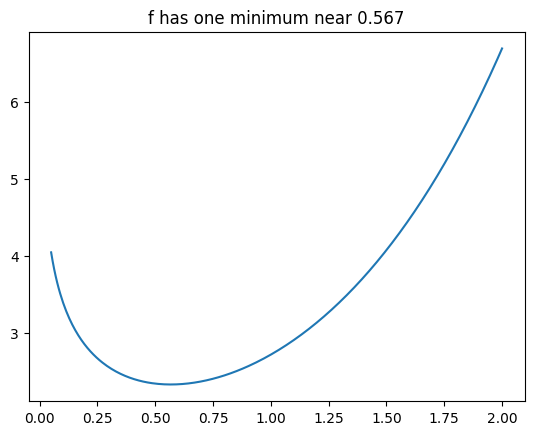

In [2]:
f=lambda x:np.exp(x)-np.log(x); df=lambda x:np.exp(x)-1/x; d2f=lambda x:np.exp(x)+1/x**2
xs=np.linspace(0.05,2,300); plt.plot(xs,f(xs)); plt.title("f has one minimum near 0.567"); plt.show()

## 2. Gradient descent: learning-rate grid

In [3]:
def gd(x0,lr,n=200):
    x=x0
    for _ in range(n):
        x=x-lr*df(x)
        if x<=0: return np.nan
    return x
for lr in (0.001,0.005,0.05,0.3,0.6): print(lr, gd(0.05,lr))

0.001 0.45583522318143654
0.005 0.5653102952041639
0.05 0.5671432904097841
0.3 nan
0.6 nan


## 3. Newton: count steps

In [4]:
x=0.05; k=0
while abs(df(x))>1e-10 and k<50: x-=df(x)/d2f(x); k+=1
print("Newton steps:",k,"x*:",x)

Newton steps: 8 x*: 0.5671432904097838


## 4. A function with two valleys: starting point matters

In [5]:
g=lambda x:x**4-3*x**3+2; dg=lambda x:4*x**3-9*x**2
def gd1(x0,lr=0.01,n=3000):
    x=x0
    for _ in range(n): x-=lr*dg(x)
    return x
print({s:round(gd1(s),3) for s in (-1,1,3)})   # from 1 or 3 GD reaches the minimum 2.25; from -1 it creeps toward the flat inflection point at 0 (slope→0 but not a minimum)

{-1: -0.004, 1: 2.25, 3: 2.25}


## 5. 2-D heat function and the Hessian

In [6]:
x_,y_=sp.symbols('x y'); T=85-sp.Rational(1,90)*x_**2*(x_-6)*y_**2*(y_-6)
gradT=sp.lambdify((x_,y_),[sp.diff(T,x_),sp.diff(T,y_)]); H=sp.lambdify((x_,y_),sp.hessian(T,(x_,y_)),'numpy')
p=np.array([0.5,0.6])
for _ in range(3000): p=p-0.05*np.array(gradT(*p))
print(p, float(T.subs({x_:p[0],y_:p[1]})), "eigenvalues of Hessian:",np.linalg.eigvalsh(np.array(H(*p),float)))

[4. 4.] 73.62222222222222 eigenvalues of Hessian: [4.2667 4.2667]


## Exercises

**Exercise 1.** Find the learning rate range for which GD on f(x)=x^2 converges (0<lr<1).

In [7]:
# your code here

**Exercise 2.** Run Newton's method on cos(x)-x from x0=1.

In [8]:
# your code here

## Solutions
*(Try the exercises first!)*

In [9]:
# Solution 1
ok=lambda lr:abs(1-2*lr)<1; assert ok(0.3) and not ok(1.2)

In [10]:
# Solution 2
x=1.0
for _ in range(8): x=x-(np.cos(x)-x)/(-np.sin(x)-1)
print(x); assert abs(x-0.7390851)<1e-6

0.7390851332151607
